# 13 — Excess Heat Factor (EHF) hazard metric

Implements the **Excess Heat Factor** (Nairn & Fawcett, 2013) as an alternative
hazard metric to TX90p day counts, motivated by two findings from earlier notebooks:

1. **Population dominance** — simple TX90p × population person-days rankings are
   functionally population maps in all three cities (Notebooks 07, 08).
2. **Spatial flatness in chronic-heat cities** — TX90p, TN90p, and degree-weighted
   magnitude all produce neighbourhood CV ≈ 0.01 in Teresina and Cáceres,
   regardless of resolution (Notebooks 12, 08).

EHF combines two components:

| Component | Formula | Captures |
|---|---|---|
| **EHI_sig** | T3 − T95_3day | How extreme the current 3-day period is vs local climatology |
| **EHI_accl** | T3 − T30 | How much hotter than what the body has recently experienced |

where T3 = 3-day trailing mean, T95_3day = 95th percentile of all T3 values,
T30 = 30-day mean of the 30 days preceding the current 3-day window.

**EHF = EHI_sig × max(1, EHI_accl)**

A heatwave day occurs when EHF > 0 (EHI_sig > 0). EHF **magnitude** — the annual
sum of EHF values — captures both frequency and intensity, and incorporates the
acclimatisation penalty for sudden heat shocks.

This notebook uses **Tmax** throughout, consistent with the TX90p framework.
All EHF computation functions live in `utils/ehf.py`.

**Prerequisites:** `01_data_acquisition`, `02_compute_baselines`.

## Setup

In [12]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import xarray as xr

sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))
from utils.heat import (
    CITIES, load_city,
    load_neighbourhood_boundaries,
    _point_in_poly_mask,
)
from utils.ehf import (
    compute_t95_3day,
    compute_ehf,
    compute_ehf_annual_stats,
    save_ehf_t95, load_ehf_t95,
    save_ehf_annual_stats, load_ehf_annual_stats,
)

DATA_DIR  = 'data'
POP_YEAR  = 2020
CITY_KEYS = ['salvador', 'teresina', 'caceres']

# ---- Load temperature series ------------------------------------------------
cities_tx = {}
for c in CITY_KEYS:
    da = load_city(c, DATA_DIR)
    da.attrs['units'] = 'degC'
    cities_tx[c] = da

# ---- Load neighbourhood boundaries ------------------------------------------
gdfs = {c: load_neighbourhood_boundaries(c, DATA_DIR) for c in CITY_KEYS}

# ---- Population grid loader -------------------------------------------------
def load_pop_grid(city, year):
    return xr.open_dataset(f'{DATA_DIR}/{city}_pop_1km_{year}.nc')['population']

salvador: shape {'time': 6497, 'lat': 55, 'lon': 67}  2003-01-01 to 2020-12-30
teresina: shape {'time': 6497, 'lat': 67, 'lon': 78}  2003-01-01 to 2020-12-30
caceres: shape {'time': 6497, 'lat': 89, 'lon': 89}  2003-01-01 to 2020-12-30
Loaded 22 neighbourhoods from cache: data/geobr_salvador_neighbourhoods_2010.gpkg
Loaded 112 neighbourhoods from cache: data/geobr_teresina_neighbourhoods_2010.gpkg
Loaded 43 neighbourhoods from cache: data/geobr_caceres_neighbourhoods_2010.gpkg


## Compute EHF T95 threshold and annual statistics

The T95_3day threshold (95th percentile of the 3-day trailing mean temperature,
computed per pixel across the full 2003–2020 record) is the EHF significance
baseline. It is cached to `data/{city}_ehf_t95_tmax.nc` on first run.

Annual statistics (heatwave day count, EHF magnitude, mean EHF intensity) are
similarly cached to `data/{city}_ehf_annual_tmax.nc`.

In [13]:
ehf_stats = {}   # city -> annual Dataset (heatwave_days, ehf_magnitude, ehf_intensity)
t95_cache = {}   # city -> T95_3day DataArray

for c in CITY_KEYS:
    label = CITIES[c]['label']

    # ---- T95 threshold (cached) ---------------------------------------------
    try:
        t95 = load_ehf_t95(c, DATA_DIR, suffix='tmax')
    except FileNotFoundError:
        print(f'{label}: computing T95_3day threshold …')
        t95 = compute_t95_3day(cities_tx[c])
        save_ehf_t95(t95, c, DATA_DIR, suffix='tmax')

    t95_cache[c] = t95

    # ---- Annual EHF statistics (cached) -------------------------------------
    try:
        ds = load_ehf_annual_stats(c, DATA_DIR, suffix='tmax')
    except FileNotFoundError:
        print(f'{label}: computing EHF time series (may take a minute) …')
        ehf = compute_ehf(cities_tx[c], t95)
        ds  = compute_ehf_annual_stats(ehf)
        save_ehf_annual_stats(ds, c, DATA_DIR, suffix='tmax')

    ehf_stats[c] = ds

    # ---- Quick sanity check --------------------------------------------------
    hd_mean  = float(ds['heatwave_days'].mean())
    mag_mean = float(ds['ehf_magnitude'].mean())
    print(
        f'{label:25s}  '
        f'T95_3day {float(t95.min()):.1f}–{float(t95.max()):.1f} °C  '
        f'mean heatwave days {hd_mean:.1f}/yr  '
        f'mean EHF magnitude {mag_mean:.1f} °C/yr'
    )

salvador EHF T95 (tmax): range 33.7–38.1 °C
Salvador, Brazil: computing EHF time series (may take a minute) …
Saved EHF annual stats: data/salvador_ehf_annual_tmax.nc
Salvador, Brazil           T95_3day 33.7–38.1 °C  mean heatwave days 5.8/yr  mean EHF magnitude 254.9 °C/yr
teresina EHF T95 (tmax): range 36.9–38.5 °C
Teresina, Brazil: computing EHF time series (may take a minute) …
Saved EHF annual stats: data/teresina_ehf_annual_tmax.nc
Teresina, Brazil           T95_3day 36.9–38.5 °C  mean heatwave days 18.0/yr  mean EHF magnitude 198.1 °C/yr
caceres EHF T95 (tmax): range 35.3–37.1 °C
Cáceres, Brazil: computing EHF time series (may take a minute) …
Saved EHF annual stats: data/caceres_ehf_annual_tmax.nc
Cáceres, Brazil            T95_3day 35.3–37.1 °C  mean heatwave days 18.0/yr  mean EHF magnitude 138.0 °C/yr


## Spatial maps — multi-year mean EHF heatwave days and magnitude

Averaging across 2003–2020 gives stable per-pixel estimates.  Compare with
the TX90p heat-day maps in Notebook 05 — EHF heatwave days should be fewer
(driven by the stricter P95 3-day mean threshold) but show stronger spatial
structure where local UHI effects push temperatures into the extreme tail.

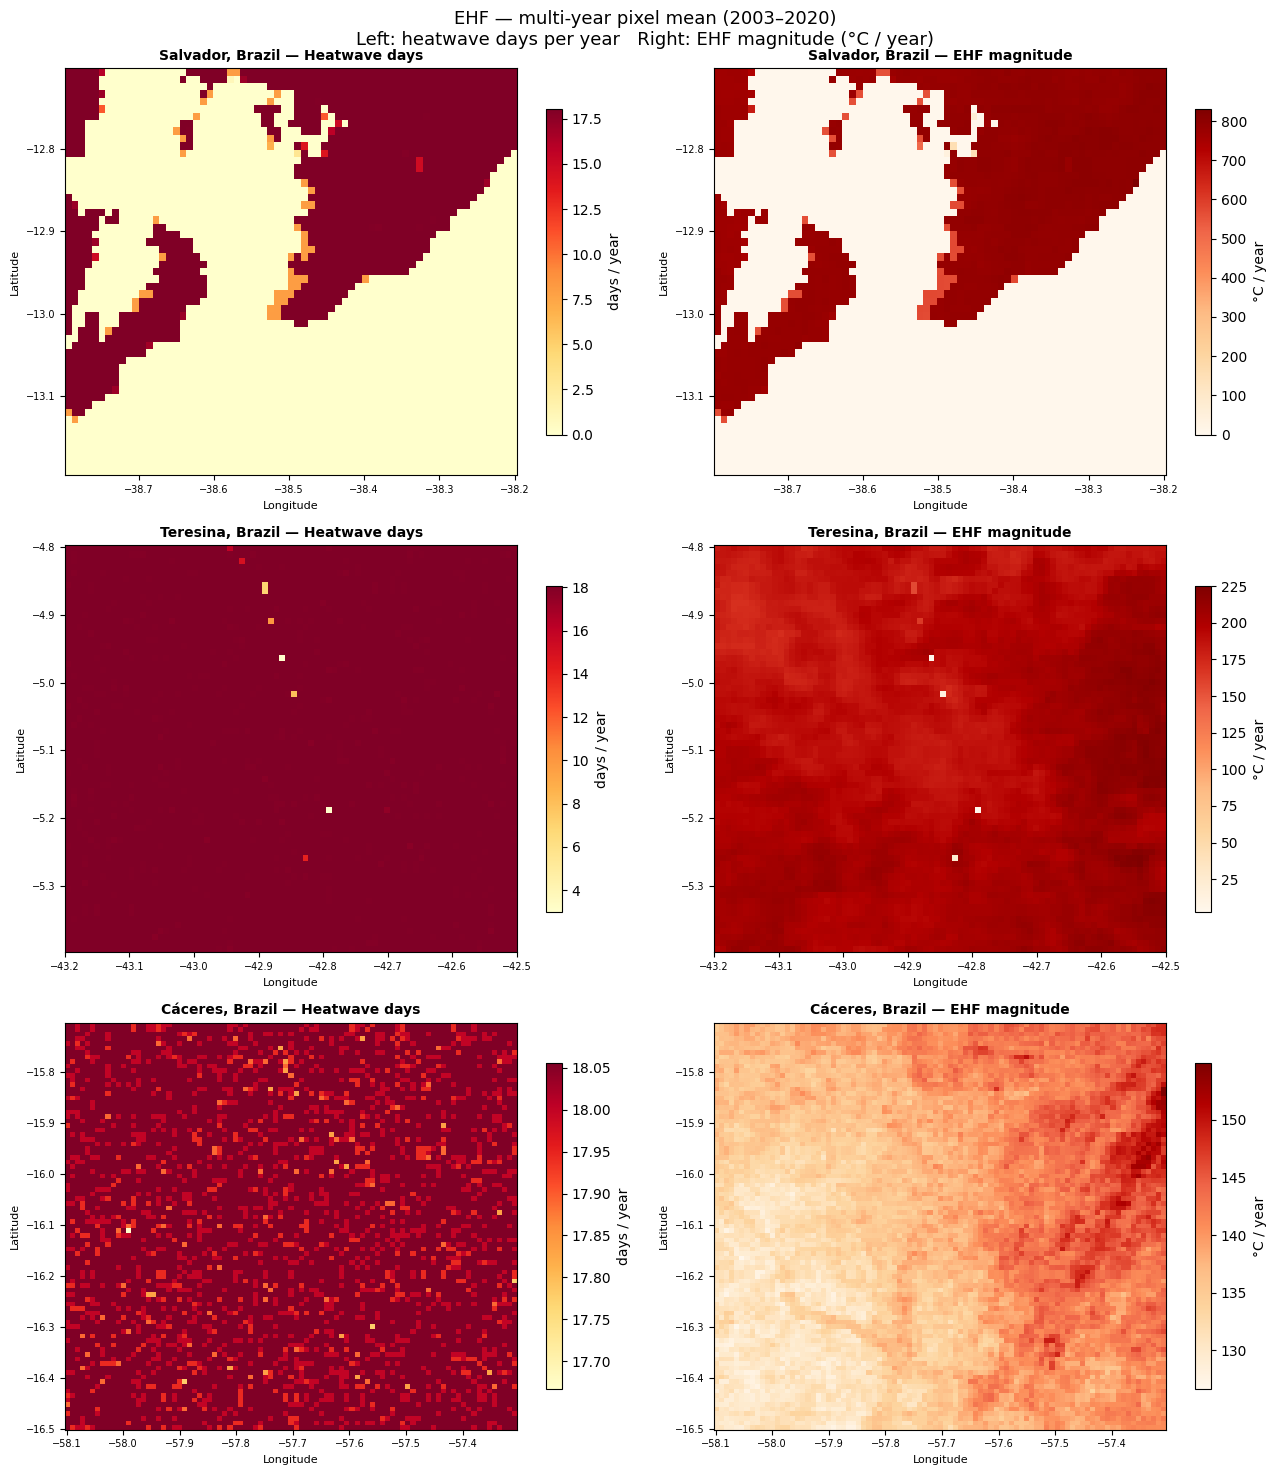

City                      Metric                   Mean      Std       CV      Min      Max
-------------------------------------------------------------------------------------
Salvador, Brazil          HW days/yr               5.77     8.34    1.445     0.00    18.06
Salvador, Brazil          EHF mag/yr             254.89   366.34    1.437     0.00   831.08

Teresina, Brazil          HW days/yr              18.02     0.42    0.023     3.00    18.06
Teresina, Brazil          EHF mag/yr             198.07    12.01    0.061     2.71   225.11

Cáceres, Brazil           HW days/yr              18.04     0.04    0.002    17.67    18.06
Cáceres, Brazil           EHF mag/yr             138.04     5.08    0.037   126.66   154.90



In [14]:
fig, axes = plt.subplots(3, 2, figsize=(13, 15))
fig.suptitle(
    'EHF — multi-year pixel mean (2003–2020)\n'
    'Left: heatwave days per year   Right: EHF magnitude (°C / year)',
    fontsize=13,
)

for row, c in enumerate(CITY_KEYS):
    ds    = ehf_stats[c]
    label = CITIES[c]['label']
    hd    = ds['heatwave_days'].mean(dim='time')
    mag   = ds['ehf_magnitude'].mean(dim='time')

    for col, (da_plot, cmap, unit) in enumerate([
        (hd,  'YlOrRd', 'days / year'),
        (mag, 'OrRd',   '°C / year'),
    ]):
        ax = axes[row][col]
        da_plot.plot(
            ax=ax, cmap=cmap,
            cbar_kwargs={'label': unit, 'shrink': 0.8},
            add_labels=False,
        )
        metric_name = 'Heatwave days' if col == 0 else 'EHF magnitude'
        ax.set_title(f'{label} — {metric_name}', fontsize=10, fontweight='bold')
        ax.set_xlabel('Longitude', fontsize=8)
        ax.set_ylabel('Latitude',  fontsize=8)
        ax.tick_params(labelsize=7)

plt.tight_layout()
plt.show()

# ---- Pixel-level summary stats ----------------------------------------------
print(f"{'City':<25} {'Metric':<20} {'Mean':>8} {'Std':>8} {'CV':>8} {'Min':>8} {'Max':>8}")
print('-' * 85)
for c in CITY_KEYS:
    ds = ehf_stats[c]
    for var, label_v in [('heatwave_days', 'HW days/yr'), ('ehf_magnitude', 'EHF mag/yr')]:
        da_mean = ds[var].mean(dim='time')
        vals = da_mean.values.flatten()
        vals = vals[np.isfinite(vals)]
        m, s = vals.mean(), vals.std()
        print(
            f'{CITIES[c]["label"]:<25} {label_v:<20} '
            f'{m:>8.2f} {s:>8.2f} {s/m:>8.3f} {vals.min():>8.2f} {vals.max():>8.2f}'
        )
    print()

## City-wide annual time series (2003–2020)

The spatial mean of EHF magnitude across all pixels shows the inter-annual
variability of heat stress at city level.  This temporal signal is meaningful
even in cities where the spatial signal is flat: a particularly bad year
is visible as a spike, which is relevant for emergency preparedness and
retrospective event attribution.

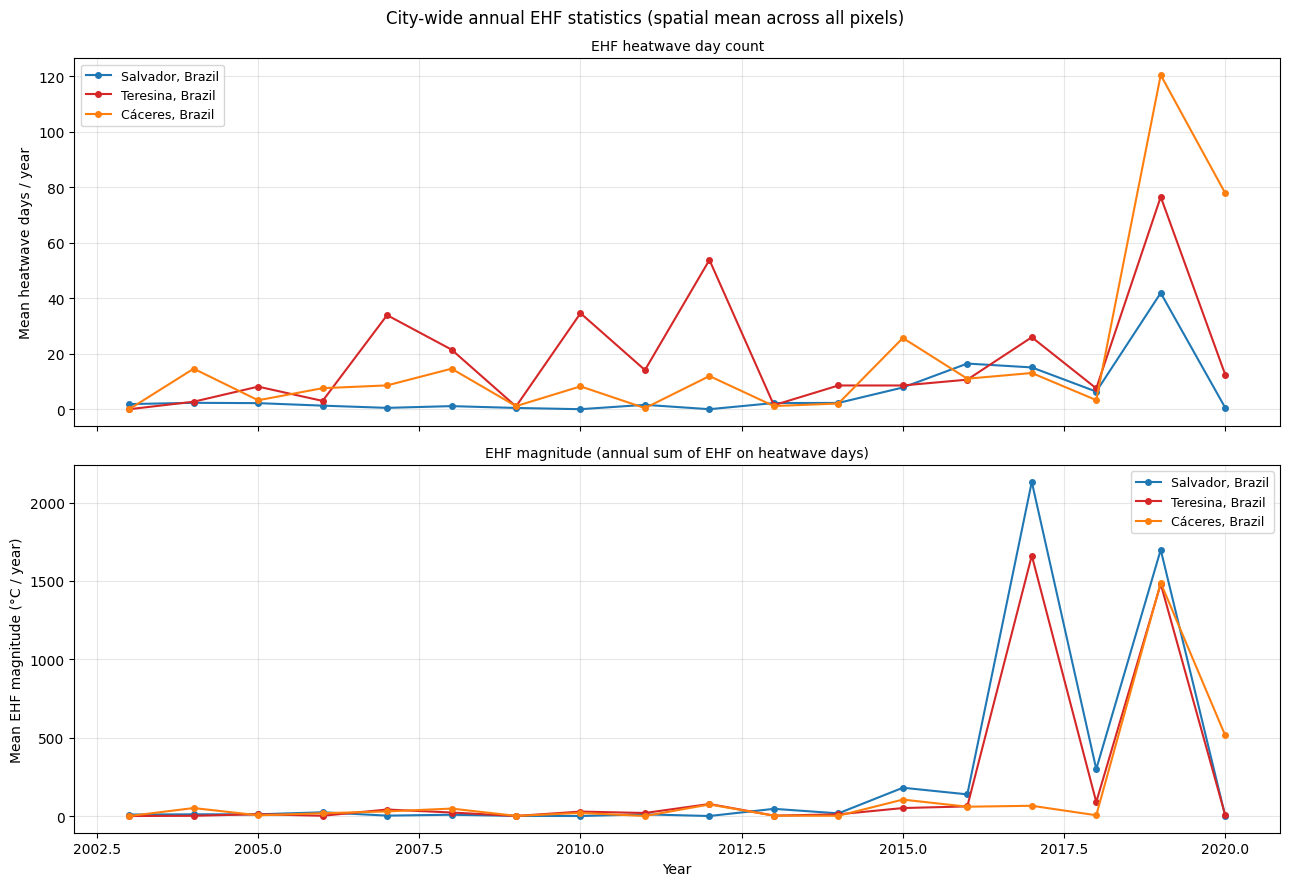

Top 3 highest EHF magnitude years per city:
  Salvador, Brazil: 2017 (2132.0 °C), 2019 (1698.4 °C), 2018 (299.2 °C)
  Teresina, Brazil: 2017 (1661.5 °C), 2019 (1480.7 °C), 2018 (89.3 °C)
  Cáceres, Brazil: 2019 (1488.0 °C), 2020 (514.1 °C), 2015 (104.8 °C)


In [15]:
fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)
fig.suptitle('City-wide annual EHF statistics (spatial mean across all pixels)', fontsize=12)

colors = {'salvador': '#1f77b4', 'teresina': '#d62728', 'caceres': '#ff7f0e'}

for c in CITY_KEYS:
    ds    = ehf_stats[c]
    label = CITIES[c]['label']
    years = ds.time.dt.year.values

    hd_city  = ds['heatwave_days'].mean(dim=['lat', 'lon'])
    mag_city = ds['ehf_magnitude'].mean(dim=['lat', 'lon'])

    axes[0].plot(years, hd_city.values,  marker='o', ms=4, lw=1.5,
                 color=colors[c], label=label)
    axes[1].plot(years, mag_city.values, marker='o', ms=4, lw=1.5,
                 color=colors[c], label=label)

axes[0].set_ylabel('Mean heatwave days / year', fontsize=10)
axes[0].set_title('EHF heatwave day count', fontsize=10)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].set_ylabel('Mean EHF magnitude (°C / year)', fontsize=10)
axes[1].set_title('EHF magnitude (annual sum of EHF on heatwave days)', fontsize=10)
axes[1].set_xlabel('Year', fontsize=10)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ---- Identify top-3 worst years per city ------------------------------------
print('Top 3 highest EHF magnitude years per city:')
for c in CITY_KEYS:
    ds    = ehf_stats[c]
    years = ds.time.dt.year.values
    mag   = ds['ehf_magnitude'].mean(dim=['lat', 'lon']).values
    top3  = np.argsort(mag)[::-1][:3]
    print(f'  {CITIES[c]["label"]}: ' +
          ', '.join(f'{years[i]} ({mag[i]:.1f} °C)' for i in top3))

## EHF component diagnostics: EHI_sig vs EHI_accl

The acclimatisation component (EHI_accl) is what distinguishes EHF from a
simple P95 exceedance count.  These plots show how often EHI_accl > 1
(the threshold above which it amplifies EHF beyond EHI_sig alone) and how the
two components combine across the record for each city.

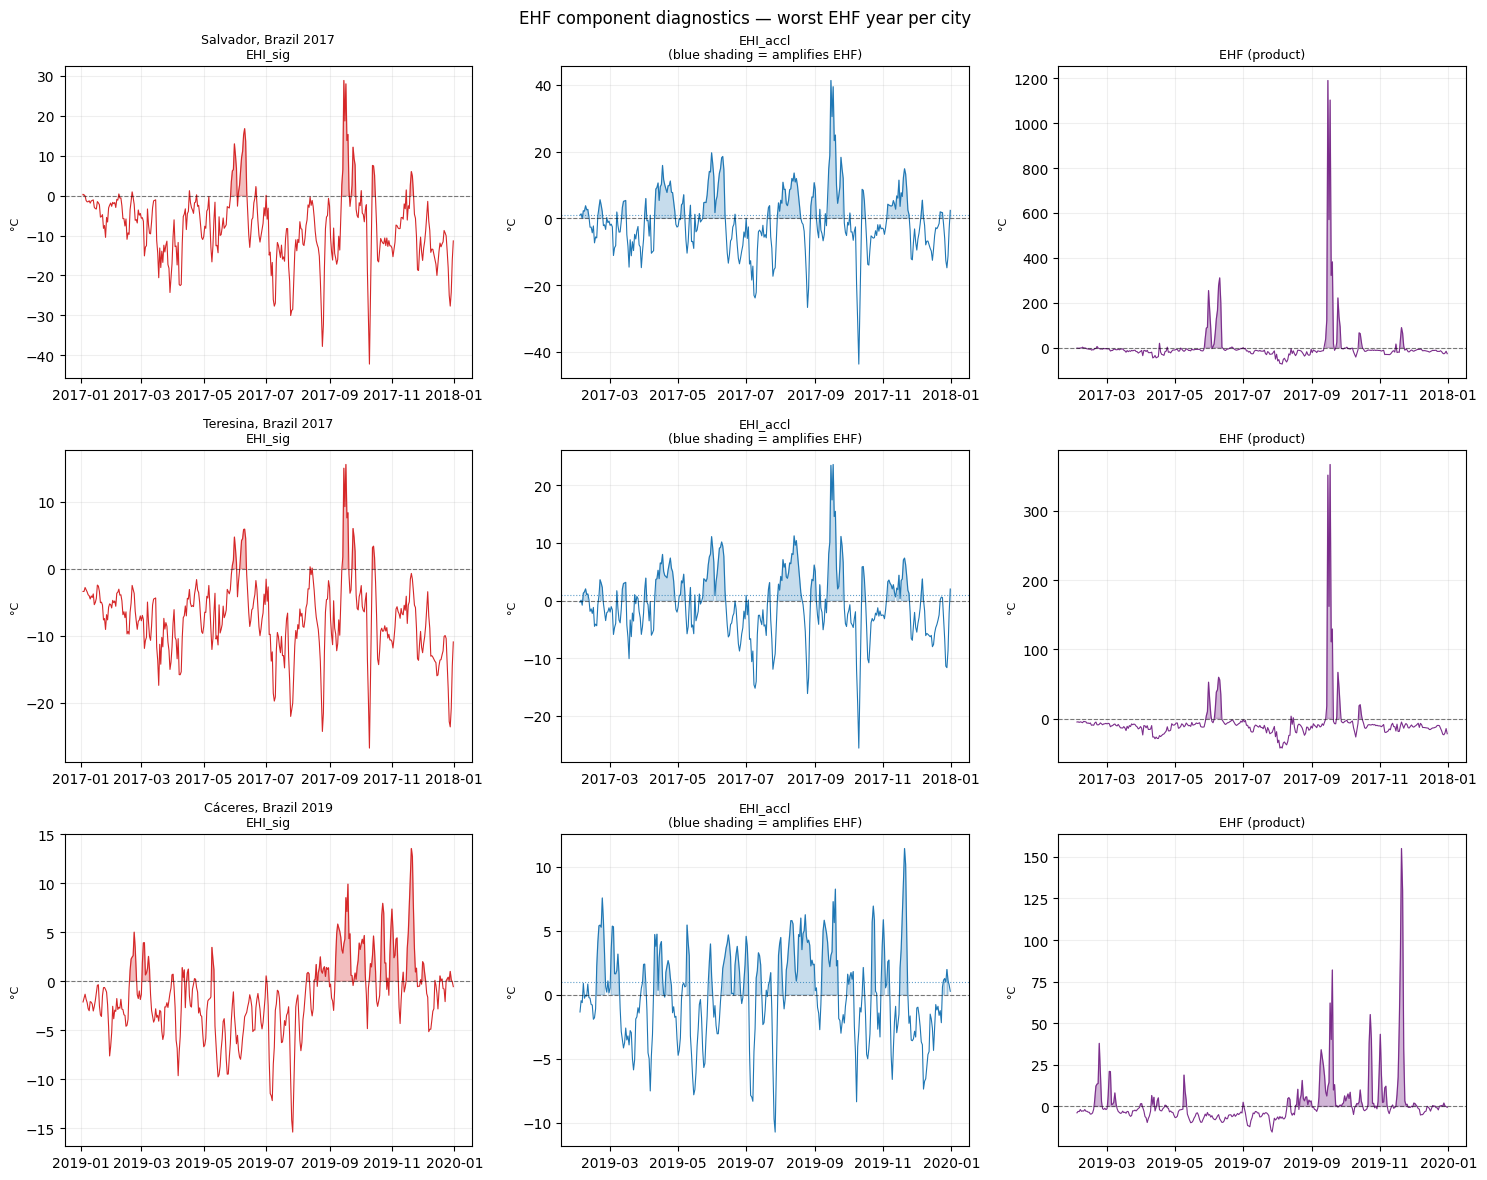

In [16]:
from utils.ehf import compute_ehf_components

# Compute components for the single worst year per city (most readable diagnostic)
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('EHF component diagnostics — worst EHF year per city', fontsize=12)

for row, c in enumerate(CITY_KEYS):
    ds    = ehf_stats[c]
    years = ds.time.dt.year.values
    mag   = ds['ehf_magnitude'].mean(dim=['lat', 'lon']).values
    worst_year = int(years[np.argmax(mag)])

    # Compute components for worst year only (saves memory)
    da_yr  = cities_tx[c].sel(time=cities_tx[c].time.dt.year == worst_year)
    t95    = t95_cache[c]
    comps  = compute_ehf_components(da_yr, t95)

    # City-mean time series for the worst year
    space_dims = [d for d in ['lat', 'lon', 'y', 'x'] if d in comps['ehf'].dims]
    ehi_sig_ts  = comps['ehi_sig'].mean(dim=space_dims).values
    ehi_accl_ts = comps['ehi_accl'].mean(dim=space_dims).values
    ehf_ts      = comps['ehf'].mean(dim=space_dims).values
    dates       = da_yr.time.values

    label = CITIES[c]['label']

    # Panel 1: EHI_sig time series
    axes[row][0].plot(dates, ehi_sig_ts, color='#d62728', lw=0.8)
    axes[row][0].axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
    axes[row][0].fill_between(dates, 0, ehi_sig_ts,
                               where=ehi_sig_ts > 0, alpha=0.3, color='#d62728')
    axes[row][0].set_title(f'{label} {worst_year}\nEHI_sig', fontsize=9)
    axes[row][0].set_ylabel('°C', fontsize=8)
    axes[row][0].grid(True, alpha=0.2)

    # Panel 2: EHI_accl time series with amplification line at 1
    axes[row][1].plot(dates, ehi_accl_ts, color='#1f77b4', lw=0.8)
    axes[row][1].axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
    axes[row][1].axhline(1, color='#1f77b4', lw=0.8, ls=':', alpha=0.7,
                          label='Amplification threshold')
    axes[row][1].fill_between(dates, 0, ehi_accl_ts,
                               where=ehi_accl_ts > 1, alpha=0.25, color='#1f77b4')
    axes[row][1].set_title(f'EHI_accl\n(blue shading = amplifies EHF)', fontsize=9)
    axes[row][1].set_ylabel('°C', fontsize=8)
    axes[row][1].grid(True, alpha=0.2)

    # Panel 3: EHF time series
    axes[row][2].plot(dates, ehf_ts, color='#7b2d8b', lw=0.8)
    axes[row][2].axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
    axes[row][2].fill_between(dates, 0, ehf_ts,
                               where=ehf_ts > 0, alpha=0.35, color='#7b2d8b')
    axes[row][2].set_title('EHF (product)', fontsize=9)
    axes[row][2].set_ylabel('°C', fontsize=8)
    axes[row][2].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

## Neighbourhood aggregation (population-weighted mean)

Aggregate the multi-year mean EHF heatwave day count and magnitude to
neighbourhood level using population-weighted means, matching the method
used in Notebook 12 for TX90p metrics.

In [17]:
def popwt_aggregate(metric_map, pop_map, gdf, col):
    """Population-weighted mean of metric_map within each neighbourhood polygon."""
    pop_aligned = pop_map.interp(
        lat=metric_map.lat, lon=metric_map.lon, method='nearest'
    ).fillna(0)

    lats = metric_map.lat.values
    lons = metric_map.lon.values
    lon_grid, lat_grid = np.meshgrid(lons, lats)
    lon_flat = lon_grid.ravel()
    lat_flat = lat_grid.ravel()
    val_flat = metric_map.values.ravel().astype(float)
    pop_flat = pop_aligned.values.ravel().astype(float)

    results = []
    for _, row in gdf.iterrows():
        mask  = _point_in_poly_mask(row.geometry, lon_flat, lat_flat)
        v     = val_flat[mask]
        p     = pop_flat[mask]
        valid = np.isfinite(v) & np.isfinite(p) & (p > 0)
        if valid.sum() > 0:
            results.append(float(np.average(v[valid], weights=p[valid])))
        else:
            finite_v = v[np.isfinite(v)]
            if len(finite_v) > 0:
                results.append(float(finite_v.mean()))
            else:
                cx, cy = row.geometry.centroid.x, row.geometry.centroid.y
                dist2  = (lon_flat - cx)**2 + (lat_flat - cy)**2
                results.append(float(val_flat[np.argmin(dist2)]))

    result      = gdf.copy()
    result[col] = results
    return result


# ---- Aggregate multi-year mean per city -------------------------------------
nbhd_ehf = {}   # city -> DataFrame

for c in CITY_KEYS:
    gdf      = gdfs[c]
    pop_grid = load_pop_grid(c, POP_YEAR)
    ds       = ehf_stats[c]

    hd_map  = ds['heatwave_days'].mean(dim='time')
    mag_map = ds['ehf_magnitude'].mean(dim='time')

    df = gdf[['name']].copy()
    df['ehf_heatwave_days'] = popwt_aggregate(hd_map,  pop_grid, gdf, 'v')['v'].values
    df['ehf_magnitude']     = popwt_aggregate(mag_map, pop_grid, gdf, 'v')['v'].values
    df = df.dropna().reset_index(drop=True)
    nbhd_ehf[c] = df

    print(
        f'{CITIES[c]["label"]:25s}  {len(df):3d} neighbourhoods  '
        f'HW days {df["ehf_heatwave_days"].min():.1f}–{df["ehf_heatwave_days"].max():.1f}  '
        f'EHF mag {df["ehf_magnitude"].min():.1f}–{df["ehf_magnitude"].max():.1f} °C'
    )

Salvador, Brazil            22 neighbourhoods  HW days 0.0–18.1  EHF mag 0.0–790.7 °C
Teresina, Brazil           112 neighbourhoods  HW days 17.5–18.1  EHF mag 180.2–201.4 °C
Cáceres, Brazil             43 neighbourhoods  HW days 17.9–18.1  EHF mag 135.7–141.3 °C


## CV comparison: EHF vs TX90p metrics

The key question: does EHF produce more spatial discrimination across
neighbourhoods than the TX90p metrics evaluated in Notebook 12?  The
TX90p reference CVs are reproduced below from that notebook for direct comparison.

In [18]:
# TX90p reference CVs from Notebook 12 (multi-year mean, pop-weighted)
TX90P_CV_REF = {
    'salvador': {'tx90p_hd': 0.485, 'tx90p_mag': 0.487},
    'teresina': {'tx90p_hd': 0.009, 'tx90p_mag': 0.014},
    'caceres':  {'tx90p_hd': 0.008, 'tx90p_mag': 0.014},
}

table_styles = [
    {'selector': 'caption', 'props': 'font-size:1em; font-weight:bold; padding-bottom:8px;'},
    {'selector': 'th', 'props': 'text-align:center; white-space:nowrap; font-size:0.85em;'},
    {'selector': 'td', 'props': 'text-align:center; font-size:0.85em;'},
]

rows = []
for c in CITY_KEYS:
    df   = nbhd_ehf[c]
    ref  = TX90P_CV_REF[c]
    row  = {'City': CITIES[c]['label'], 'N': len(df)}

    for col, label in [('ehf_heatwave_days', 'EHF HW days'),
                       ('ehf_magnitude',     'EHF magnitude')]:
        mean = df[col].mean()
        cv   = df[col].std() / mean if mean > 0 else np.nan
        row[f'{label} mean'] = round(mean, 2)
        row[f'{label} CV']   = round(cv, 3)

    row['TX90p days CV (nb12)'] = ref['tx90p_hd']
    row['TX mag CV (nb12)']     = ref['tx90p_mag']
    rows.append(row)

summary = pd.DataFrame(rows).set_index('City')

cv_cols = ['EHF HW days CV', 'EHF magnitude CV',
           'TX90p days CV (nb12)', 'TX mag CV (nb12)']

display(
    summary
    .style
    .format({c: '{:.3f}' for c in cv_cols})
    .format({'N': '{:.0f}',
             'EHF HW days mean': '{:.2f}',
             'EHF magnitude mean': '{:.2f}'})
    .background_gradient(subset=cv_cols, cmap='YlOrRd', axis=None)
    .set_caption(
        'CV = std / mean across neighbourhoods  |  '
        'EHF metrics are multi-year means 2003–2020, pop-weighted  |  '
        'TX90p reference CVs from Notebook 12'
    )
    .set_table_styles(table_styles)
)

,N,EHF HW days mean,EHF HW days CV,EHF magnitude mean,EHF magnitude CV,TX90p days CV (nb12),TX mag CV (nb12)
City,,,,,,,
"Salvador, Brazil",22,11.86,0.479000,593.70,0.389000,0.485000,0.487000
"Teresina, Brazil",112,18.03,0.004000,188.08,0.019000,0.009000,0.014000
"Cáceres, Brazil",43,18.04,0.002000,138.71,0.009000,0.008000,0.014000


## CV bar chart — EHF vs TX90p (shared axis)

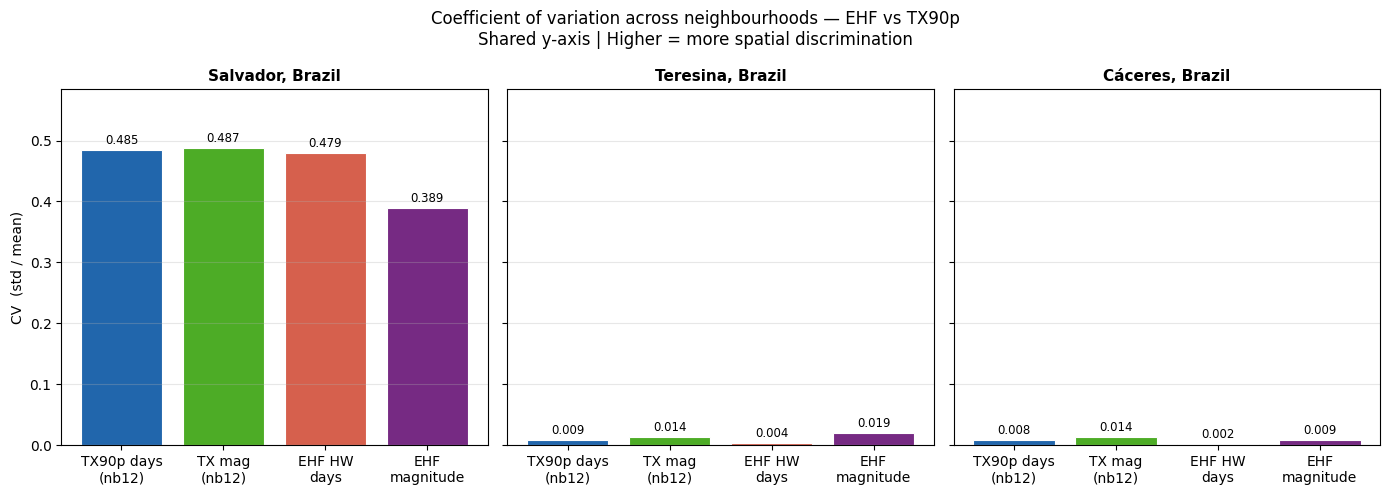

In [19]:
metric_keys    = ['TX90p days\n(nb12)', 'TX mag\n(nb12)',
                  'EHF HW\ndays', 'EHF\nmagnitude']
metric_colors  = ['#2166ac', '#4dac26', '#d6604d', '#762a83']

# Collect CVs in same order
all_cv = {}
for c in CITY_KEYS:
    df  = nbhd_ehf[c]
    ref = TX90P_CV_REF[c]
    ehf_hd_cv  = df['ehf_heatwave_days'].std() / df['ehf_heatwave_days'].mean()
    ehf_mag_cv = df['ehf_magnitude'].std()      / df['ehf_magnitude'].mean()
    all_cv[c]  = [ref['tx90p_hd'], ref['tx90p_mag'], ehf_hd_cv, ehf_mag_cv]

global_max = max(v for cvs in all_cv.values() for v in cvs)

fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)
fig.suptitle(
    'Coefficient of variation across neighbourhoods — EHF vs TX90p\n'
    'Shared y-axis | Higher = more spatial discrimination',
    fontsize=12,
)

for ax, c in zip(axes, CITY_KEYS):
    cvs  = all_cv[c]
    bars = ax.bar(metric_keys, cvs, color=metric_colors,
                  edgecolor='white', linewidth=0.8)
    for bar, v in zip(bars, cvs):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            v + global_max * 0.01,
            f'{v:.3f}',
            ha='center', va='bottom', fontsize=8.5,
        )
    ax.set_title(CITIES[c]['label'], fontsize=11, fontweight='bold')
    ax.set_ylim(0, global_max * 1.2)
    ax.grid(True, axis='y', alpha=0.3)

axes[0].set_ylabel('CV  (std / mean)', fontsize=10)
plt.tight_layout()
plt.show()

## Summary

The results should be read alongside the findings in `HEAT_METRIC_FINDINGS.md`
and Notebook 12. Key questions to check from the outputs above:

**Does EHF magnitude out-discriminate TX90p magnitude in Salvador?**  
The acclimatisation component (EHI_accl) should amplify events following cooler
periods, which are more common in Salvador than in Teresina. If EHF magnitude
CV > TX magnitude CV in Salvador, this is the mechanism at work.

**Does EHF produce any lift in Teresina and Cáceres?**  
Because the acclimatisation baseline (T30) is itself always elevated in chronically
hot cities, EHI_accl is frequently near zero. EHF will still be positive on days
where EHI_sig > 0 (3-day mean > T95), but the magnitude amplification from
EHI_accl is suppressed. Any CV lift over TX90p is likely modest.

**What does the time series show?**  
Even where spatial CV is low, the annual time series may reveal significant
inter-annual variability, including identifiable worst years (La Niña, drought
years, regional heat dome events). This temporal signal is operationally useful
for retrospective assessment and climate trend detection.

**Recommended next step:**  
If EHF magnitude CV remains ≈ TX90p magnitude CV in Teresina and Cáceres,
the chronic-heat conclusion from `HEAT_METRIC_FINDINGS.md` stands: use
EHF magnitude as the hazard metric (best health-literature grounding) but
drive within-city neighbourhood prioritisation for those cities primarily
through the vulnerability/adaptive-capacity layer.

---
## EHF with Tmin (nighttime temperature)

Repeats the full EHF analysis using daily minimum temperature (Tmin) rather than
Tmax.  The health motivation is that **nocturnal heat prevents physiological
recovery**: core body temperature accumulated during the day cannot dissipate if
nights stay hot, which is the primary mechanism behind the highest mortality spikes
during heatwaves.

Two additional notes:

- **Cáceres anticorrelation** — Notebook 09 found ρ(TX90p, TN90p) = −0.452 in
  Cáceres: areas with the most daytime heat have the *fewest* warm nights.  EHF(Tmin)
  will therefore identify a different set of neighbourhoods than EHF(Tmax) for that city.
- **Salvador grid** — the Tmin GSHTD grid for Salvador has 48 latitude rows vs 55
  for Tmax.  Both are resampled to their own native grids; direct pixel-level
  comparison is not meaningful, but neighbourhood-level population-weighted
  aggregation is unaffected.

In [20]:
from utils.heat import load_city_tmin

# ---- Load Tmin series -------------------------------------------------------
cities_tn = {}
for c in CITY_KEYS:
    da = load_city_tmin(c, DATA_DIR)
    da.attrs['units'] = 'degC'
    cities_tn[c] = da

# ---- Compute / load cached EHF(Tmin) ----------------------------------------
ehf_stats_tn = {}
t95_cache_tn = {}

for c in CITY_KEYS:
    label = CITIES[c]['label']

    try:
        t95 = load_ehf_t95(c, DATA_DIR, suffix='tmin')
    except FileNotFoundError:
        print(f'{label}: computing T95_3day (Tmin) …')
        t95 = compute_t95_3day(cities_tn[c])
        save_ehf_t95(t95, c, DATA_DIR, suffix='tmin')

    t95_cache_tn[c] = t95

    try:
        ds = load_ehf_annual_stats(c, DATA_DIR, suffix='tmin')
    except FileNotFoundError:
        print(f'{label}: computing EHF(Tmin) time series …')
        ehf = compute_ehf(cities_tn[c], t95)
        ds  = compute_ehf_annual_stats(ehf)
        save_ehf_annual_stats(ds, c, DATA_DIR, suffix='tmin')

    ehf_stats_tn[c] = ds

    hd_mean  = float(ds['heatwave_days'].mean())
    mag_mean = float(ds['ehf_magnitude'].mean())
    print(
        f'{label:25s}  '
        f'T95_3day(Tmin) {float(t95.min()):.1f}–{float(t95.max()):.1f} °C  '
        f'mean heatwave days {hd_mean:.1f}/yr  '
        f'mean EHF magnitude {mag_mean:.1f} °C/yr'
    )

salvador: shape {'time': 6496, 'lat': 48, 'lon': 67}  2003-01-01 to 2020-12-30
teresina: shape {'time': 6496, 'lat': 67, 'lon': 78}  2003-01-01 to 2020-12-30
caceres: shape {'time': 6496, 'lat': 89, 'lon': 89}  2003-01-01 to 2020-12-30
Salvador, Brazil: computing T95_3day (Tmin) …


/Users/martynclark/heatInsights-notebooks/venv/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,


Saved EHF T95 threshold: data/salvador_ehf_t95_tmin.nc
Salvador, Brazil: computing EHF(Tmin) time series …
Saved EHF annual stats: data/salvador_ehf_annual_tmin.nc
Salvador, Brazil           T95_3day(Tmin) 23.7–25.5 °C  mean heatwave days 6.3/yr  mean EHF magnitude 6.7 °C/yr
Teresina, Brazil: computing T95_3day (Tmin) …
Saved EHF T95 threshold: data/teresina_ehf_t95_tmin.nc
Teresina, Brazil: computing EHF(Tmin) time series …
Saved EHF annual stats: data/teresina_ehf_annual_tmin.nc
Teresina, Brazil           T95_3day(Tmin) 24.1–25.7 °C  mean heatwave days 17.7/yr  mean EHF magnitude 7.6 °C/yr
Cáceres, Brazil: computing T95_3day (Tmin) …
Saved EHF T95 threshold: data/caceres_ehf_t95_tmin.nc
Cáceres, Brazil: computing EHF(Tmin) time series …
Saved EHF annual stats: data/caceres_ehf_annual_tmin.nc
Cáceres, Brazil            T95_3day(Tmin) 22.2–24.6 °C  mean heatwave days 17.9/yr  mean EHF magnitude 16.9 °C/yr


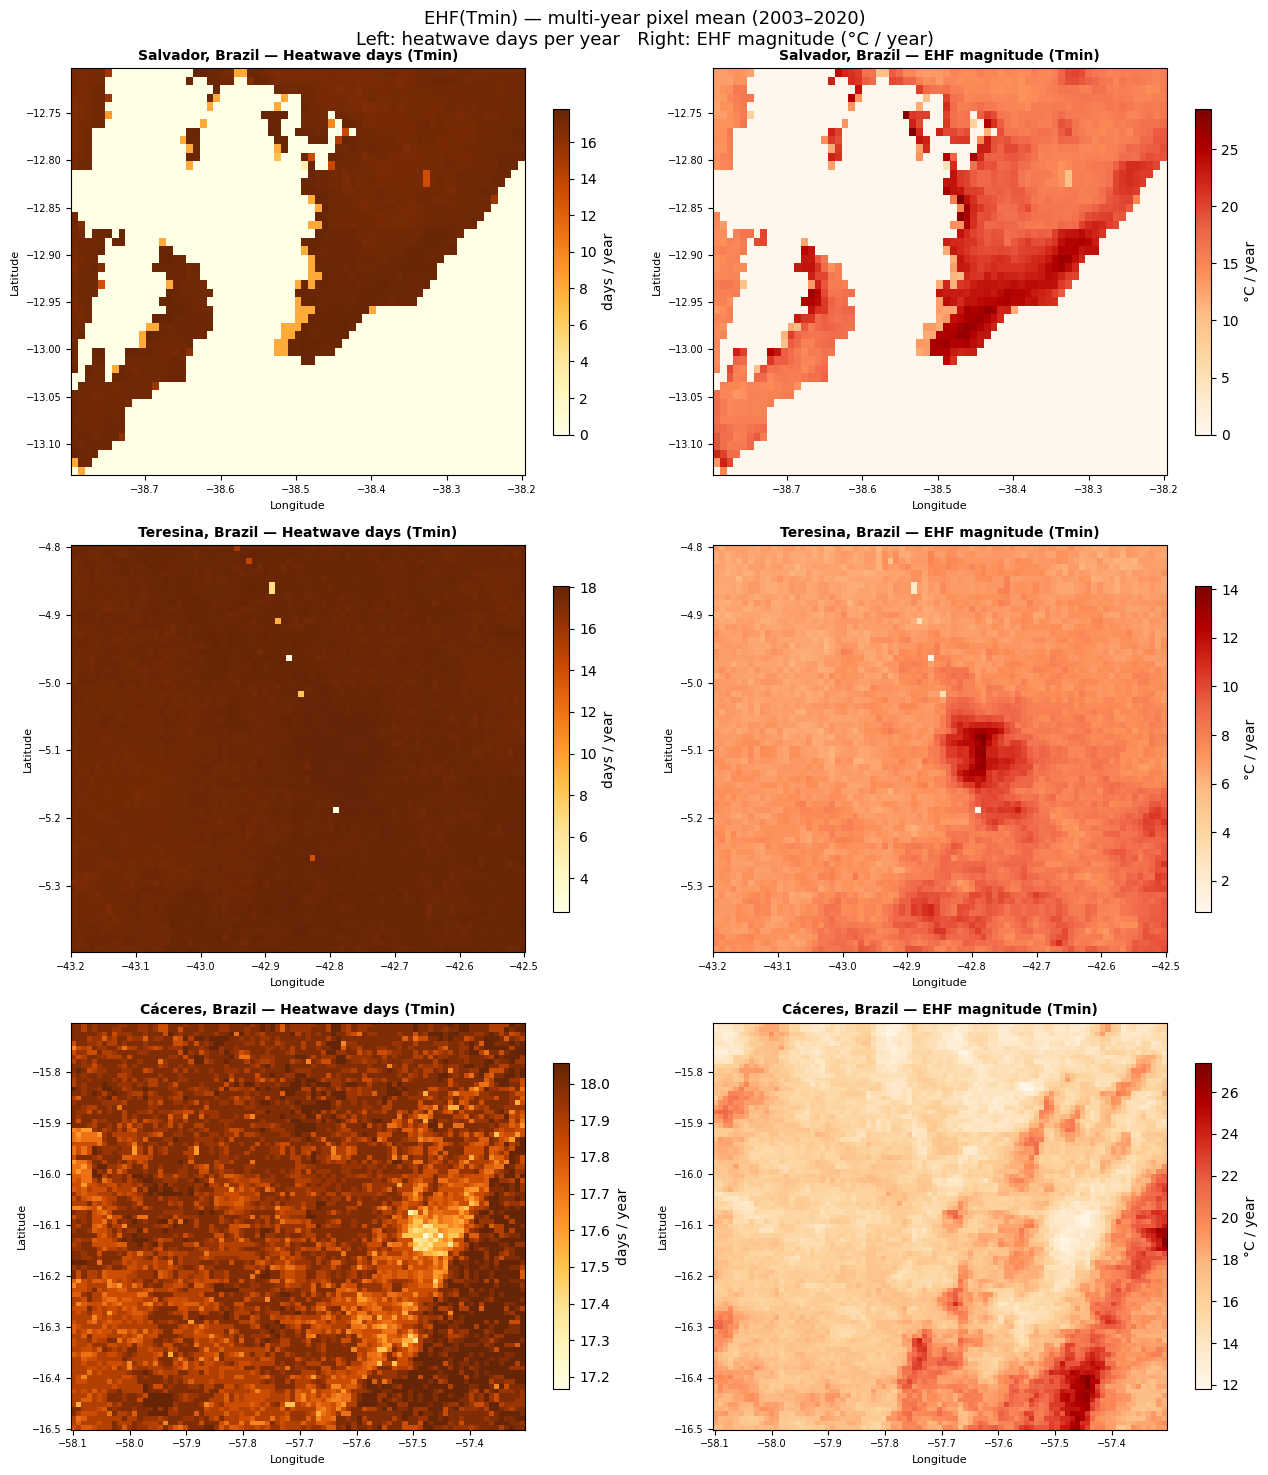

City                      Metric                     Mean      Std       CV      Min      Max
---------------------------------------------------------------------------------------
Salvador, Brazil          HW days/yr (Tmin)          6.35     8.26    1.302     0.00    17.83
Salvador, Brazil          EHF mag/yr (Tmin)          6.70     8.91    1.329     0.00    28.56

Teresina, Brazil          HW days/yr (Tmin)         17.74     0.44    0.025     2.39    18.06
Teresina, Brazil          EHF mag/yr (Tmin)          7.59     1.08    0.142     0.73    14.12

Cáceres, Brazil           HW days/yr (Tmin)         17.93     0.11    0.006    17.17    18.06
Cáceres, Brazil           EHF mag/yr (Tmin)         16.92     2.30    0.136    11.80    27.38



In [21]:
# ---- Spatial maps: EHF(Tmin) ------------------------------------------------
fig, axes = plt.subplots(3, 2, figsize=(13, 15))
fig.suptitle(
    'EHF(Tmin) — multi-year pixel mean (2003–2020)\n'
    'Left: heatwave days per year   Right: EHF magnitude (°C / year)',
    fontsize=13,
)

for row, c in enumerate(CITY_KEYS):
    ds    = ehf_stats_tn[c]
    label = CITIES[c]['label']
    hd    = ds['heatwave_days'].mean(dim='time')
    mag   = ds['ehf_magnitude'].mean(dim='time')

    for col, (da_plot, cmap, unit) in enumerate([
        (hd,  'YlOrBr', 'days / year'),
        (mag, 'OrRd',   '°C / year'),
    ]):
        ax = axes[row][col]
        da_plot.plot(ax=ax, cmap=cmap,
                     cbar_kwargs={'label': unit, 'shrink': 0.8},
                     add_labels=False)
        metric_name = 'Heatwave days (Tmin)' if col == 0 else 'EHF magnitude (Tmin)'
        ax.set_title(f'{label} — {metric_name}', fontsize=10, fontweight='bold')
        ax.set_xlabel('Longitude', fontsize=8)
        ax.set_ylabel('Latitude',  fontsize=8)
        ax.tick_params(labelsize=7)

plt.tight_layout()
plt.show()

# ---- Pixel-level summary stats ----------------------------------------------
print(f"{'City':<25} {'Metric':<22} {'Mean':>8} {'Std':>8} {'CV':>8} {'Min':>8} {'Max':>8}")
print('-' * 87)
for c in CITY_KEYS:
    ds = ehf_stats_tn[c]
    for var, lbl in [('heatwave_days', 'HW days/yr (Tmin)'),
                     ('ehf_magnitude', 'EHF mag/yr (Tmin)')]:
        da_mean = ds[var].mean(dim='time')
        vals = da_mean.values.flatten()
        vals = vals[np.isfinite(vals)]
        m, s = vals.mean(), vals.std()
        print(
            f'{CITIES[c]["label"]:<25} {lbl:<22} '
            f'{m:>8.2f} {s:>8.2f} {s/m:>8.3f} {vals.min():>8.2f} {vals.max():>8.2f}'
        )
    print()

In [22]:
# ---- Neighbourhood aggregation: EHF(Tmin) -----------------------------------
nbhd_ehf_tn = {}

for c in CITY_KEYS:
    gdf      = gdfs[c]
    pop_grid = load_pop_grid(c, POP_YEAR)
    ds       = ehf_stats_tn[c]

    hd_map  = ds['heatwave_days'].mean(dim='time')
    mag_map = ds['ehf_magnitude'].mean(dim='time')

    df = gdf[['name']].copy()
    df['ehf_heatwave_days_tn'] = popwt_aggregate(hd_map,  pop_grid, gdf, 'v')['v'].values
    df['ehf_magnitude_tn']     = popwt_aggregate(mag_map, pop_grid, gdf, 'v')['v'].values
    df = df.dropna().reset_index(drop=True)
    nbhd_ehf_tn[c] = df

    print(
        f'{CITIES[c]["label"]:25s}  {len(df):3d} neighbourhoods  '
        f'HW days {df["ehf_heatwave_days_tn"].min():.1f}–{df["ehf_heatwave_days_tn"].max():.1f}  '
        f'EHF mag {df["ehf_magnitude_tn"].min():.1f}–{df["ehf_magnitude_tn"].max():.1f} °C'
    )

Salvador, Brazil            22 neighbourhoods  HW days 0.0–17.7  EHF mag 0.0–23.5 °C
Teresina, Brazil           112 neighbourhoods  HW days 17.4–18.1  EHF mag 7.6–13.9 °C
Cáceres, Brazil             43 neighbourhoods  HW days 17.8–18.1  EHF mag 16.0–21.7 °C


In [23]:
# TN90p reference CVs from Notebook 12
TN90P_CV_REF = {
    'salvador': {'tn90p_hd': 0.481, 'tn90p_mag': 0.475},
    'teresina': {'tn90p_hd': 0.010, 'tn90p_mag': 0.008},
    'caceres':  {'tn90p_hd': 0.010, 'tn90p_mag': 0.009},
}

# ---- Full CV comparison table: all 6 metrics --------------------------------
rows = []
for c in CITY_KEYS:
    df_tx = nbhd_ehf[c]
    df_tn = nbhd_ehf_tn[c]
    ref_tx = TX90P_CV_REF[c]
    ref_tn = TN90P_CV_REF[c]

    def cv(s): return s.std() / s.mean() if s.mean() > 0 else np.nan

    rows.append({
        'City':                   CITIES[c]['label'],
        'TX90p days\n(nb12)':     ref_tx['tx90p_hd'],
        'TX mag\n(nb12)':         ref_tx['tx90p_mag'],
        'EHF(Tmax)\nHW days':     cv(df_tx['ehf_heatwave_days']),
        'EHF(Tmax)\nmagnitude':   cv(df_tx['ehf_magnitude']),
        'TN90p days\n(nb12)':     ref_tn['tn90p_hd'],
        'TN mag\n(nb12)':         ref_tn['tn90p_mag'],
        'EHF(Tmin)\nHW days':     cv(df_tn['ehf_heatwave_days_tn']),
        'EHF(Tmin)\nmagnitude':   cv(df_tn['ehf_magnitude_tn']),
    })

summary_full = pd.DataFrame(rows).set_index('City')

cv_cols = [c for c in summary_full.columns]
display(
    summary_full
    .style
    .format({c: '{:.3f}' for c in cv_cols})
    .background_gradient(subset=cv_cols, cmap='YlOrRd', axis=None)
    .set_caption(
        'CV = std / mean across neighbourhoods (pop-weighted, multi-year mean 2003–2020)\n'
        'TX90p / TN90p reference CVs from Notebook 12'
    )
    .set_table_styles(table_styles)
)

,TX90p days (nb12),TX mag (nb12),EHF(Tmax) HW days,EHF(Tmax) magnitude,TN90p days (nb12),TN mag (nb12),EHF(Tmin) HW days,EHF(Tmin) magnitude
City,,,,,,,,
"Salvador, Brazil",0.485,0.487,0.479,0.389,0.481,0.475,0.473,0.436
"Teresina, Brazil",0.009,0.014,0.004,0.019,0.010,0.008,0.005,0.138
"Cáceres, Brazil",0.008,0.014,0.002,0.009,0.010,0.009,0.004,0.082


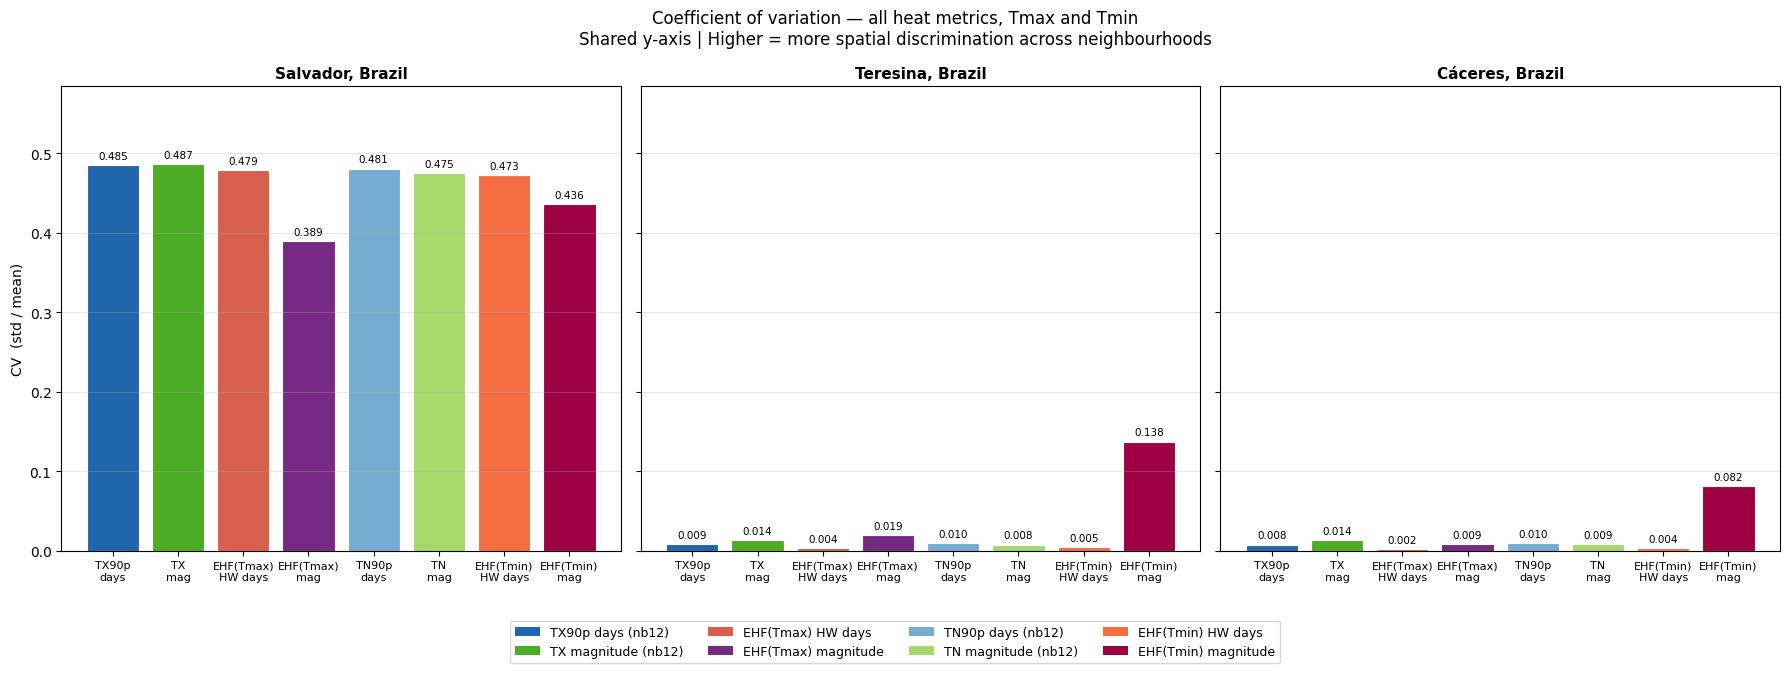

In [24]:
# ---- Bar chart: all 8 metrics, shared y-axis --------------------------------
metric_keys = [
    'TX90p\ndays', 'TX\nmag',
    'EHF(Tmax)\nHW days', 'EHF(Tmax)\nmag',
    'TN90p\ndays', 'TN\nmag',
    'EHF(Tmin)\nHW days', 'EHF(Tmin)\nmag',
]
metric_colors = [
    '#2166ac', '#4dac26',      # TX90p
    '#d6604d', '#762a83',      # EHF(Tmax)
    '#74add1', '#a6d96a',      # TN90p
    '#f46d43', '#9e0142',      # EHF(Tmin)
]

all_cv_full = {}
for c in CITY_KEYS:
    df_tx = nbhd_ehf[c]
    df_tn = nbhd_ehf_tn[c]
    ref_tx = TX90P_CV_REF[c]
    ref_tn = TN90P_CV_REF[c]
    def cv(s): return s.std() / s.mean() if s.mean() > 0 else 0.0
    all_cv_full[c] = [
        ref_tx['tx90p_hd'],  ref_tx['tx90p_mag'],
        cv(df_tx['ehf_heatwave_days']),  cv(df_tx['ehf_magnitude']),
        ref_tn['tn90p_hd'],  ref_tn['tn90p_mag'],
        cv(df_tn['ehf_heatwave_days_tn']),  cv(df_tn['ehf_magnitude_tn']),
    ]

global_max = max(v for cvs in all_cv_full.values() for v in cvs)

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
fig.suptitle(
    'Coefficient of variation — all heat metrics, Tmax and Tmin\n'
    'Shared y-axis | Higher = more spatial discrimination across neighbourhoods',
    fontsize=12,
)

for ax, c in zip(axes, CITY_KEYS):
    cvs  = all_cv_full[c]
    bars = ax.bar(metric_keys, cvs, color=metric_colors,
                  edgecolor='white', linewidth=0.8)
    for bar, v in zip(bars, cvs):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            v + global_max * 0.01,
            f'{v:.3f}',
            ha='center', va='bottom', fontsize=7.5,
        )
    ax.set_title(CITIES[c]['label'], fontsize=11, fontweight='bold')
    ax.set_ylim(0, global_max * 1.2)
    ax.grid(True, axis='y', alpha=0.3)
    ax.tick_params(axis='x', labelsize=8)

axes[0].set_ylabel('CV  (std / mean)', fontsize=10)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2166ac', label='TX90p days (nb12)'),
    Patch(facecolor='#4dac26', label='TX magnitude (nb12)'),
    Patch(facecolor='#d6604d', label='EHF(Tmax) HW days'),
    Patch(facecolor='#762a83', label='EHF(Tmax) magnitude'),
    Patch(facecolor='#74add1', label='TN90p days (nb12)'),
    Patch(facecolor='#a6d96a', label='TN magnitude (nb12)'),
    Patch(facecolor='#f46d43', label='EHF(Tmin) HW days'),
    Patch(facecolor='#9e0142', label='EHF(Tmin) magnitude'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=4,
           fontsize=9, bbox_to_anchor=(0.5, -0.12))
plt.tight_layout()
plt.show()